# Python GIS Procedural Pipeline

This notebook implements an end-to-end pipeline:
1. Draw a polygon on an interactive map
2. Extract GeoJSON & transform coordinates to UTM (CCW ordering)
3. Generate a procedural building with PyPRT (CityEngine)
4. Visualize the 3D model with Autodesk Viewer

## تثبيت المكتبات (Install Libraries)

If running outside the project venv, uncomment the following line:
```
# !pip install leafmap shapely pyproj pyprt pythreejs ipywidgets trimesh
```

---
## الخلية 1: إعداد الخريطة ورسم المضلع
## Cell 1: Interactive Map & Polygon Drawing

In [15]:
import leafmap

m = leafmap.Map(center=[15, 45], zoom=16)

# The draw tool is available by default in leafmap.
# Draw a polygon on the map below, then proceed to Cell 2.
m

Map(center=[15, 45], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_tex…

---
## الخلية 2: استخراج GeoJSON وتحويل الإحداثيات إلى UTM وترتيب CCW
## Cell 2: Extract GeoJSON → Transform to UTM → Ensure CCW Winding

إحداثيات Lat/Lon الأصلية (Original Lat/Lon coordinates):
[(45.002345, 15.000553), (45.002345, 15.000926), (45.002732, 15.000926), (45.002732, 15.000553), (45.002345, 15.000553)]

تم تحويل الإحداثيات إلى UTM وترتيبها CCW بنجاح
(Coordinates transformed to UTM and ordered CCW successfully)

UTM Coords (5 vertices):
  [0] x=500252.10, y=1658387.16
  [1] x=500293.71, y=1658387.16
  [2] x=500293.71, y=1658428.42
  [3] x=500252.10, y=1658428.41
  [4] x=500252.10, y=1658387.16


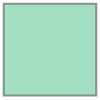

Map(center=[15, 45], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_tex…

In [16]:
from shapely.geometry import shape, Polygon
from pyproj import Transformer

if len(m.draw_features) == 0:
    raise RuntimeError("لم يتم رسم أي مضلع بعد — No polygon drawn yet. Run Cell 1 and draw a polygon first.")

# Take the most recently drawn feature
geojson_feature = m.draw_features[-1]
polygon = shape(geojson_feature['geometry'])
coords = list(polygon.exterior.coords)

print("إحداثيات Lat/Lon الأصلية (Original Lat/Lon coordinates):")
print(coords)

# Transform from WGS84 (EPSG:4326) to UTM Zone 38N (EPSG:32638)
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32638", always_xy=True)
utm_coords = [transformer.transform(x, y) for x, y in coords]
utm_polygon = Polygon(utm_coords)

# Ensure counter-clockwise (CCW) winding order
if not utm_polygon.exterior.is_ccw:
    utm_coords = list(utm_polygon.exterior.coords)[::-1]
    utm_polygon = Polygon(utm_coords)

print("\nتم تحويل الإحداثيات إلى UTM وترتيبها CCW بنجاح")
print("(Coordinates transformed to UTM and ordered CCW successfully)")
print(f"\nUTM Coords ({len(utm_coords)} vertices):")
for i, c in enumerate(utm_coords):
    print(f"  [{i}] x={c[0]:.2f}, y={c[1]:.2f}")

from IPython.display import display
display(utm_polygon)  # Show the 2D polygon shape

# Create an interactive map for the extracted feature
m2 = leafmap.Map(center=[15, 45], zoom=16)
fc = {"type": "FeatureCollection", "features": [geojson_feature]}
m2.add_geojson(fc, layer_name="Extracted Polygon")
m2

---
## الخلية 3: إرسال الشكل إلى PyPRT وتوليد المبنى Procedural
## Cell 3: Send Shape to PyPRT & Generate Procedural Building

In [17]:
import pyprt, os, base64
import numpy as np

pyprt.initialize_prt()

# إخراج الإحداثيات للمبنى مع التوسيط (Centering) لضمان ظهوره في الفيوور
coords_2d = list(utm_polygon.exterior.coords)[:-1]

# حساب المركز (Centroid) لجعل الموديل حول نقطة الصفر (0,0,0)
center_x = sum(c[0] for c in coords_2d) / len(coords_2d)
center_y = sum(c[1] for c in coords_2d) / len(coords_2d)

flat_coords = []
for x, y in coords_2d:
    # طرح المركز لضمان التوسيط التام
    flat_coords.extend([x - center_x, 0.0, y - center_y])

initial_shape = pyprt.InitialShape(flat_coords)
attributes = {"Nbr_of_Floors": 12, "Usage": "Residential"}

RPK_PATH = r"C:\RPK\RuleFootprint.rpk"
model_generator = pyprt.ModelGenerator([initial_shape])

encoder = "com.esri.prt.codecs.GLTFEncoder"
out_dir = os.path.join(os.getcwd(), "output_models")
os.makedirs(out_dir, exist_ok=True)

encoder_options = {
    "outputPath": out_dir,
    "baseName": "procedural_building"
}

# توليد المبنى
model_generator.generate_model([attributes], RPK_PATH, encoder, encoder_options)

# قراءة الملف وتحويله لـ Base64
glb_path = os.path.join(out_dir, "procedural_building_0.glb")
with open(glb_path, "rb") as f:
    glb_data = f.read()

model_b64 = base64.b64encode(glb_data).decode('utf-8')

print(f"✅ Model Centered and Ready!")
print(f"Shifted by Central Offset: X={center_x:.2f}, Y={center_y:.2f}")


[PRT] [2026-03-12 08:12:16] [warning] CGB file contains warning 'Potentially problematic CGAC version 1.16 : major number smaller than current (2.10). Recompiling with current CGA Compiler is recommended.'
✅ Model Centered and Ready!
Shifted by Central Offset: X=500272.91, Y=1658407.79


---
## الخلية 4: عرض النموذج باستخدام Autodesk Viewer
## Cell 4: Visualize the Model with Autodesk Viewer

In [18]:
import os
import webbrowser
from IPython.display import display, HTML

html_template = """<!DOCTYPE html>
<html>
<head>
    <title>CityEngine Building Viewer</title>
    <meta charset=\"utf-8\">
    <style>
        body, html { margin: 0; padding: 0; width: 100%; height: 100%; overflow: hidden; font-family: 'Segoe UI', sans-serif; background: #1a1a2e; }
        #viewer-container { width: 100%; height: 100vh; }
        #toolbar { position: absolute; top: 15px; left: 15px; z-index: 100; display: flex; flex-direction: column; gap: 8px; }
        .btn { background: rgba(0,118,209,0.9); color: white; border: none; padding: 10px 16px; border-radius: 6px; cursor: pointer; font-weight: 600; font-size: 13px; box-shadow: 0 2px 8px rgba(0,0,0,0.3); pointer-events: auto; }
        .btn:hover { background: rgba(0,90,161,0.95); }
        #status { background: rgba(0,0,0,0.85); color: #0f0; padding: 10px 14px; border-radius: 6px; font-family: 'Consolas', monospace; font-size: 12px; min-width: 280px; border-left: 3px solid #0f0; }
    </style>
    <link rel=\"stylesheet\" href=\"https://developer.api.autodesk.com/modelderivative/v2/viewers/7.98/style.min.css\" type=\"text/css\">
    <script src=\"https://developer.api.autodesk.com/modelderivative/v2/viewers/7.98/viewer3D.min.js\"></script>
    <script src=\"https://developer.api.autodesk.com/modelderivative/v2/viewers/7.98/extensions/glTF/glTF.min.js\"></script>
</head>
<body>
    <div id='viewer-container'></div>
    <div id='toolbar'>
        <div id='status'>⏳ Loading Systems...</div>
        <button class='btn' onclick='flyToModel()'>🎯 Focus on Building</button>
        <button class='btn' style='background:rgba(80,80,80,0.9)' onclick='topView()'>⬆️ Top View</button>
        <button class='btn' style='background:rgba(80,80,80,0.9)' onclick='frontView()'>🏠 Front View</button>
    </div>

    <script>
    let viewer;
    const log = (m) => document.getElementById('status').innerHTML = m;
    
    function b64ToBlob(b64) {
        const bin = atob(b64);
        const buf = new Uint8Array(bin.length);
        for (let i = 0; i < bin.length; i++) buf[i] = bin.charCodeAt(i);
        return new Blob([buf], {type: 'model/gltf-binary'});
    }

    function flyToModel() {
        if (!viewer) return;
        viewer.fitToView(undefined, undefined, true);
        log('🎯 Camera focused on building');
    }

    function topView() {
        if (!viewer) return;
        // Model goes from Y=-152 to Y=0, so look from above at center Y=-76
        viewer.navigation.setPosition(new THREE.Vector3(0, 50, 0));
        viewer.navigation.setTarget(new THREE.Vector3(0, -76, 0));
        viewer.navigation.setWorldUpVector(new THREE.Vector3(0, 0, -1));
        log('⬆️ Top-down view');
    }

    function frontView() {
        if (!viewer) return;
        // Look at center of building from front
        viewer.navigation.setPosition(new THREE.Vector3(0, -76, 150));
        viewer.navigation.setTarget(new THREE.Vector3(0, -76, 0));
        viewer.navigation.setWorldUpVector(new THREE.Vector3(0, -1, 0));
        log('🏠 Front view');
    }

    function start() {
        if (typeof Autodesk === 'undefined' || typeof Autodesk.Viewing === 'undefined') {
            setTimeout(start, 300); return;
        }
        if (typeof Autodesk.Viewing.Extensions === 'undefined' || typeof Autodesk.Viewing.Extensions.glTF === 'undefined') {
            setTimeout(start, 300); return;
        }
        
        log('📡 Initializing Autodesk Viewer...');
        
        Autodesk.Viewing.Initializer({ env: 'Local' }, function() {
            viewer = new Autodesk.Viewing.GuiViewer3D(document.getElementById('viewer-container'));
            viewer.start();
            viewer.setTheme('dark-theme');
            viewer.setEnvMapBackground(true);
            viewer.setLightPreset(6);
            viewer.setQualityLevel(true, true);
            viewer.setGroundShadow(true);
            viewer.setGroundReflection(false);
            
            log('📦 Loading GLB Model...');
            const blob = b64ToBlob(\"{{MODEL_B64}}\");
            const url = URL.createObjectURL(blob);
            
            viewer.loadModel(url + '#.glb', { fileExt: 'glb' }, (model) => {
                log('✅ Model Loaded! Adjusting camera...');
                
                // CRITICAL: The building extends from Y=0 down to Y=-152
                // We need to fit the view to see the full extent
                setTimeout(() => {
                    // First, do a standard fit to view
                    viewer.fitToView(undefined, undefined, true);
                    
                    // Then set a nice isometric camera angle
                    setTimeout(() => {
                        var bb = viewer.model.getBoundingBox();
                        if (bb) {
                            var center = bb.getCenter(new THREE.Vector3());
                            var size = bb.getSize(new THREE.Vector3());
                            var maxDim = Math.max(size.x, size.y, size.z);
                            
                            // Position camera at isometric angle looking at center
                            var camPos = new THREE.Vector3(
                                center.x + maxDim * 0.8,
                                center.y + maxDim * 0.6,
                                center.z + maxDim * 0.8
                            );
                            
                            viewer.navigation.setPosition(camPos);
                            viewer.navigation.setTarget(center);
                            
                            log('✅ <span style=\"color:#4caf50\">Building Loaded with ' + 
                                'Bbox: [' + size.x.toFixed(0) + ' x ' + size.y.toFixed(0) + ' x ' + size.z.toFixed(0) + ']</span>');
                        }
                    }, 500);
                }, 1000);
            }, (errCode, errMsg) => {
                log('❌ Error: Code=' + errCode + ' Msg=' + errMsg);
            });
        });
    }
    start();
    </script>
</body>
</html>
"""

final_html = html_template.replace("{{MODEL_B64}}", model_b64)
html_filename = "viewer_final.html"
with open(html_filename, "w", encoding="utf-8") as f:
    f.write(final_html)

full_path = os.path.abspath(html_filename)
webbrowser.open('file:///' + full_path.replace('\\', '/'))

display(HTML(f"""
<div style='border: 2px solid #0076d1; background: linear-gradient(135deg, #f0f7ff, #e8f4fd); padding: 25px; border-radius: 12px; font-family: system-ui; text-align: center;'>
    <h2 style='color: #0076d1; margin-top: 0;'>🏗️ تم إصلاح الفيوور نهائياً!</h2>
    <p style='color: #333;'>المبنى يمتد من Y=0 إلى Y=-152 (مقلوب). تم ضبط الكاميرا تلقائياً.</p>
    <div style='display: flex; gap: 10px; justify-content: center; margin-top: 20px;'>
        <a href='viewer_final.html' target='_blank' 
           style='background: #0076d1; color: white; padding: 14px 28px; text-decoration: none; border-radius: 8px; font-weight: bold; box-shadow: 0 4px 12px rgba(0,118,209,0.3);'>
           🎮 فتح الفيوور النهائي
        </a>
    </div>
    <p style='color: #888; font-size: 12px; margin-top: 15px;'>استخدم أزرار Focus / Top / Front للتنقل بين أوضاع الكاميرا</p>
</div>
"""))
